In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [ ]:
data = pd.read_csv("Train.csv")

print("Shape of Dataset:", data.shape)
data.head()

Shape of Dataset: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [ ]:
cluster_features = data[["Cost_of_the_Product", "Weight_in_gms"]]

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

In [ ]:
kmeans_model = KMeans(n_clusters=3, random_state=0)

cluster_labels = kmeans_model.fit_predict(scaled_features)

data["Shipment_Cluster"] = cluster_labels

In [ ]:
print("Cluster Centers (Scaled Values):")
print(kmeans_model.cluster_centers_)

Cluster Centers (Scaled Values):
[[ 0.96268269 -0.92098031]
 [-0.17587094  0.7854062 ]
 [-1.10495078 -1.15327789]]


In [ ]:
cluster_analysis = data.groupby("Shipment_Cluster")[["Cost_of_the_Product","Weight_in_gms"]].mean()

print(cluster_analysis)

                  Cost_of_the_Product  Weight_in_gms
Shipment_Cluster                                    
0                          256.426692     2134.77735
1                          201.657143     4920.02224
2                          157.064460     1747.45180


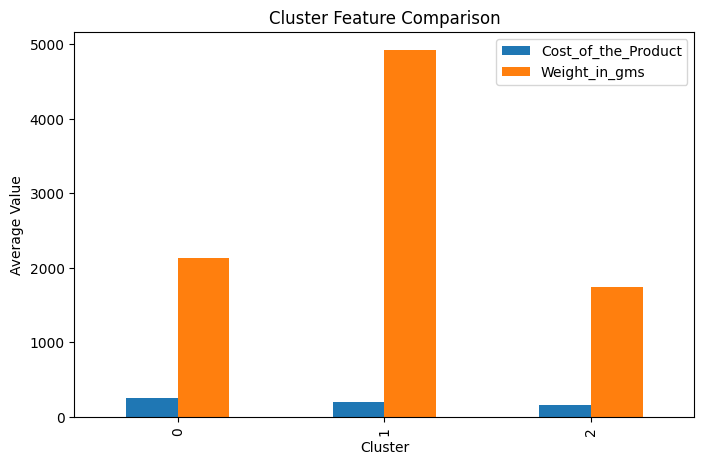

In [ ]:
cluster_analysis.plot(kind="bar", figsize=(8,5))

plt.title("Cluster Feature Comparison")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.show()

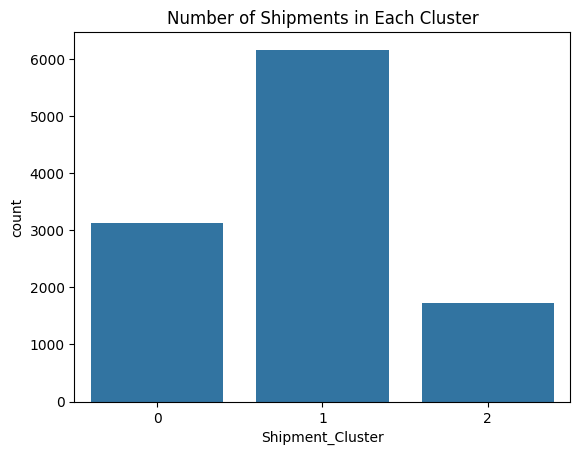

In [ ]:
sns.countplot(x="Shipment_Cluster", data=data)

plt.title("Number of Shipments in Each Cluster")
plt.show()

In [ ]:
X = data.drop("Reached.on.Time_Y.N", axis=1)
y = data["Reached.on.Time_Y.N"]

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
kbest_selector = SelectKBest(score_func=f_classif, k=5)

X_selected = kbest_selector.fit_transform(X_encoded, y)

In [ ]:
selected_columns = X_encoded.columns[kbest_selector.get_support()]

print("Top Selected Features:")
print(selected_columns)

Top Selected Features:
Index(['ID', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms',
       'Shipment_Cluster'],
      dtype='object')
